# 02 — Crank-Nicolson y Convergencia hacia Black-Scholes

**Módulo 2** del pipeline de valoración de opciones.

Este notebook:
1. Resuelve la PDE de Black-Scholes vía Crank-Nicolson (`CrankNicolson`)
2. Calcula el precio analítico exacto (`BlackScholesAnalitico`) como benchmark
3. Verifica el orden de convergencia $\mathcal{O}(\Delta t^2, \Delta S^2)$
4. Contrasta $\hat{P}(S_T>K)$ de Monte Carlo (notebook `01`) contra $\mathcal{N}(d_2)$ — la prima de riesgo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))

import config
from src.resultados_io import cargar_pde, cargar_convergencia, cargar_monte_carlo

plt.rcParams["figure.figsize"] = (10, 5)

## BS ≡ Ecuación de Calor de Fourier

El cambio de variables $\tau = T-t$, $x=\ln(S/K)$, $u = V\cdot e^{\alpha x+\beta\tau}$
transforma la PDE de Black-Scholes en la ecuación de calor clásica:

$$\underbrace{\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S} - rV = 0}_{\text{PDE de Black-Scholes}}
\quad\xrightarrow{\text{cambio de variables}}\quad
\underbrace{\frac{\partial u}{\partial \tau} = \frac{\partial^2 u}{\partial x^2}}_{\text{Ecuación de calor}}$$

Esta equivalencia es la que justifica aplicar Crank-Nicolson , método
estándar de física computacional para la ecuación de calor, a un problema de finanzas cuantitativas.

## Parámetros del contrato

In [9]:
pde = cargar_pde()

S0, K, T, r, sigma = pde["S0"], pde["K"], pde["T"], pde["r"], pde["sigma"]
TIPO = pde["tipo"]

print(f"S0    = {S0:.2f}")
print(f"K     = {K:.2f}")
print(f"T     = {T:.4f} años")
print(f"r     = {r:.4f}")
print(f"sigma = {sigma:.4f}  (MLE, notebook 01)")
print(f"tipo  = {TIPO}")

S0    = 194.83
K     = 195.00
T     = 0.5370 años
r     = 0.0500
sigma = 0.4776  (MLE, notebook 01)
tipo  = call


## Resolución Crank-Nicolson vs Black-Scholes analítico

Crank-Nicolson promedia los esquemas explícito e implícito con peso ½,
logrando precisión $\mathcal{O}(\Delta t^2, \Delta S^2)$ y estabilidad. La solución analítica de Black-Scholes actúa como benchmark exacto para validar el resultado numérico.

In [3]:
precio_cn = pde["precio_cn"]
precio_exacto = pde["precio_bs"]
error = abs(precio_cn - precio_exacto)

print(f"Precio Crank-Nicolson : {precio_cn:.6f}")
print(f"Precio BS analítico   : {precio_exacto:.6f}")
print(f"Error absoluto        : {error:.6f}")
print(f"Error relativo        : {error / precio_exacto:.4%}")

Precio Crank-Nicolson : 29.295819
Precio BS analítico   : 29.290537
Error absoluto        : 0.005282
Error relativo        : 0.0180%


## Superficie de la solución $V(S, t=0)$

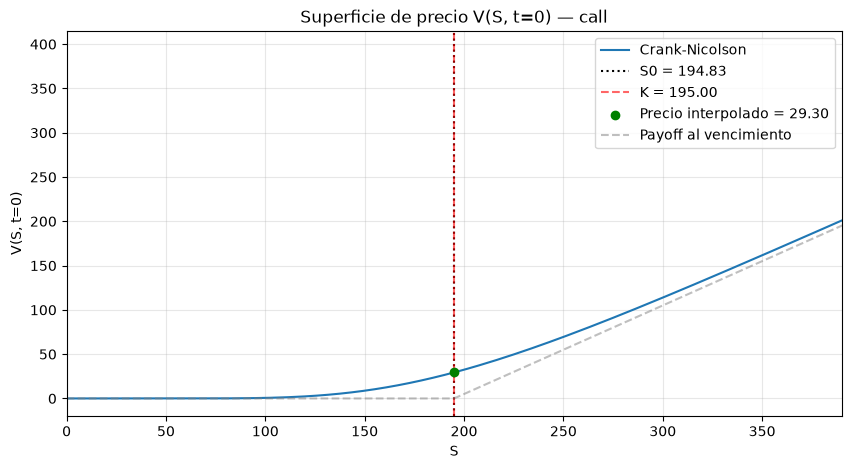

In [4]:
malla_S, malla_V = pde["malla_S"], pde["malla_V"]

plt.plot(malla_S, malla_V, label="Crank-Nicolson", linewidth=1.5)
plt.axvline(S0, color="black", linestyle=":", label=f"S0 = {S0:.2f}")
plt.axvline(K, color="red", linestyle="--", label=f"K = {K:.2f}", alpha=0.6)
plt.scatter([S0], [precio_cn], color="green", zorder=5,
            label=f"Precio interpolado = {precio_cn:.2f}")

payoff = np.maximum(malla_S - K, 0) if TIPO == "call" else np.maximum(K - malla_S, 0)
plt.plot(malla_S, payoff, "--", color="gray", alpha=0.5, label="Payoff al vencimiento")

plt.title(f"Superficie de precio V(S, t=0) — {TIPO}")
plt.xlabel("S")
plt.ylabel("V(S, t=0)")
plt.xlim(0, K * 2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Análisis de convergencia

Refinando la malla sucesivamente (duplicando $M$ y $N$ en cada paso), el
error debería caer consistentemente con orden $\mathcal{O}(\Delta t^2, \Delta S^2)$.
El orden empírico se calcula como:

$$\text{orden} = \log_2\!\left(\frac{\text{error}_i}{\text{error}_{i+1}}\right)$$

Si Crank-Nicolson logra el orden teórico, este valor debería acercarse a **2**
en cada refinamiento.

In [ ]:
tabla_convergencia = cargar_convergencia()
tabla_convergencia

,M,N,dt,dS,precio_CN,precio_exacto,error,orden_empirico
0,25,25,0.021479,23.400000,29.586012,29.290537,0.295474,NaN
1,50,50,0.010740,11.700000,29.372343,29.290537,0.081805,1.852767
2,100,100,0.005370,5.850000,29.308855,29.290537,0.018318,2.158935
3,200,200,0.002685,2.925000,29.295840,29.290537,0.005303,1.788504
4,400,400,0.001342,1.462500,29.291440,29.290537,0.000902,2.555358
5,800,800,0.000671,0.731250,29.290879,29.290537,0.000341,1.401916
6,1600,1600,0.000336,0.365625,29.290573,29.290537,0.000036,3.264097


## Visualización de la convergencia (escala log-log)

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_32692\246863151.py:8: SyntaxWarning: invalid escape sequence '\D'
  ax.loglog(dt_ref, error_ref, "--", color="gray", label="Referencia $O(\Delta t^2)$")
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_32692\246863151.py:10: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel("$\Delta t$")


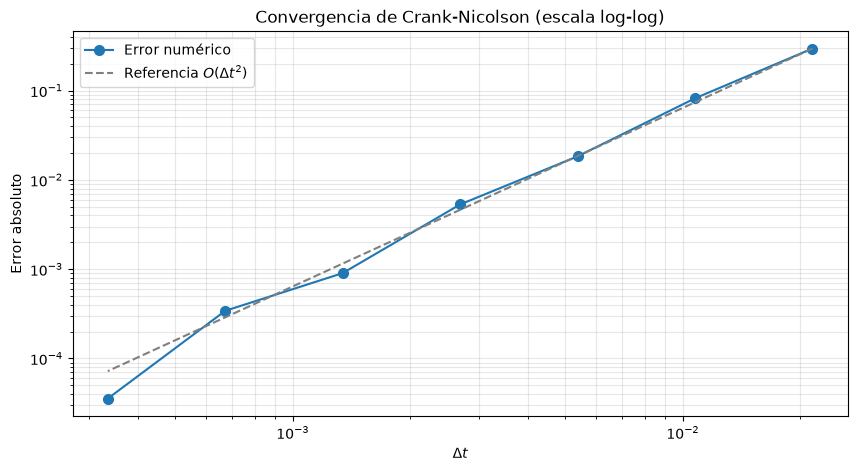


Orden de convergencia empírico por refinamiento:
   M    N    error  orden_empirico
  25   25 0.295474             NaN
  50   50 0.081805        1.852767
 100  100 0.018318        2.158935
 200  200 0.005303        1.788504
 400  400 0.000902        2.555358
 800  800 0.000341        1.401916
1600 1600 0.000036        3.264097


In [6]:
fig, ax = plt.subplots()

ax.loglog(tabla_convergencia["dt"], tabla_convergencia["error"], "o-",
           label="Error numérico", linewidth=1.5, markersize=7)

dt_ref = tabla_convergencia["dt"].values
error_ref = tabla_convergencia["error"].iloc[0] * (dt_ref / dt_ref[0])**2
ax.loglog(dt_ref, error_ref, "--", color="gray", label="Referencia $O(\Delta t^2)$")

ax.set_xlabel("$\Delta t$")
ax.set_ylabel("Error absoluto")
ax.set_title("Convergencia de Crank-Nicolson (escala log-log)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

print("\nOrden de convergencia empírico por refinamiento:")
print(tabla_convergencia[["M", "N", "error", "orden_empirico"]].to_string(index=False))

## Prima de riesgo — Monte Carlo (medida P) vs Black-Scholes (medida Q)

In [ ]:
mc = cargar_monte_carlo()
prob_empirica_montecarlo = mc["prob_itm"]

prob_riesgo_neutral = pde["prob_riesgo_neutral"]
etiqueta = "N(d2)" if TIPO == "call" else "N(-d2)"
prima_riesgo = prob_empirica_montecarlo - prob_riesgo_neutral

print(f"P(S_T > K) empírica (medida P, Monte Carlo) : {prob_empirica_montecarlo:.4f}")
print(f"{etiqueta} (medida Q, Black-Scholes)         : {prob_riesgo_neutral:.4f}")
print(f"Prima de riesgo (P - Q)                       : {prima_riesgo:+.4f}")

if prima_riesgo > 0:
    print("\n-> mu > r: el mercado exige compensación por el riesgo de mantener el activo")
elif prima_riesgo < 0:
    print("\n-> mu < r: caso atípico, revisar calibración de mu")
else:
    print("\n-> prima de riesgo nula (mu ≈ r)")

P(S_T > K) empírica (medida P, Monte Carlo) : 0.6267
N(d2) (medida Q, Black-Scholes)         : 0.4599
Prima de riesgo (P - Q)                       : +0.1669

-> mu > r: el mercado exige compensación por el riesgo de mantener el activo


## Resumen — valores que viajan al siguiente notebook

| Variable | Valor | Destino |
|---|---|---|
| `cn` (objeto `CrankNicolson` resuelto) | malla completa | Input de `Griegas` en notebook 03 |
| `cn.precio` | precio numérico hoy | Comparación final |
| `precio_exacto` | precio analítico BS | Benchmark para validar griegas |
| Orden de convergencia empírico | ≈ 2 (esperado) | Validación del Objetivo 1 |

In [8]:
print(f"Precio final (Crank-Nicolson) : {precio_cn:.4f}")
print(f"Precio final (BS analítico)    : {precio_exacto:.4f}")
print(f"sigma usada                    : {sigma:.4f}")
print(f"r usada                        : {r:.4f}")

Precio final (Crank-Nicolson) : 29.2958
Precio final (BS analítico)    : 29.2905
sigma usada                    : 0.4776
r usada                        : 0.0500
